In [1]:
import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
print(project_root)

c:\Users\abd93000\PycharmProjects\cnt_project_v2\testing\Notebooks\Use_case_CNT_orientation_analysis\Use_case_CNT_orientation_analysis


## Generate synthetic sample

In [3]:
import numpy as np
from src.synthetic_data import generate_segments_image
import cv2

import sys
import importlib
importlib.reload(sys.modules['src.synthetic_data'])

<module 'src.synthetic_data' from 'c:\\Users\\abd93000\\PycharmProjects\\cnt_project_v2\\testing\\Notebooks\\Use_case_CNT_orientation_analysis\\Use_case_CNT_orientation_analysis\\src\\synthetic_data.py'>

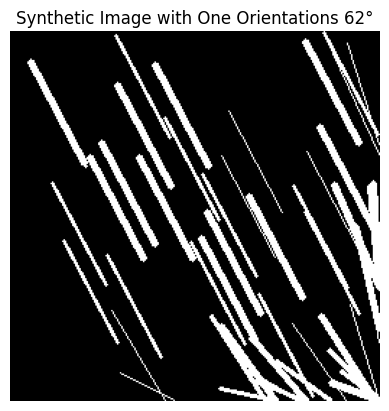

In [4]:
# First orientation
or1 = 62#np.random.randint(0, 180)
# or2 = np.random.randint(0, 180)

# Second orientation, drawn on top of the first
img1 = generate_segments_image(img_size=256, num_segments=50, main_angle_deg=or1, angle_std_deg=0, length_range=(80,81))
# img2 = generate_segments_image(img_size=256, num_segments=50, main_angle_deg=or2, angle_std_deg=0, length_range=(20,21),
#                                base_image=img1)


img2 = img1.copy()
title_synthetic_image = f'Synthetic Image with One Orientations {or1}°'
#title_synthetic_image = f'Synthetic Image with Two Orientations {or1}° and {or2}°'
img = img2[:,:,0]

# Display the combined image
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(title_synthetic_image)
plt.axis('off')
plt.show()
# 

# FFT Orientation Extraction

In [5]:
import sys
import os
import pandas as pd, os, random, cv2
import importlib

# Add the project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.fft_utils import extract_fft_features
from src.io_utils import list_images
from src.orientation_metrics import find_main_orientation
from src.visualization import show_angle_orientation

importlib.reload(sys.modules['src.orientation_metrics'])
importlib.reload(sys.modules['src.visualization'])
importlib.reload(sys.modules['src.fft_utils'])

<module 'src.fft_utils' from 'c:\\Users\\abd93000\\PycharmProjects\\cnt_project_v2\\testing\\Notebooks\\Use_case_CNT_orientation_analysis\\Use_case_CNT_orientation_analysis\\src\\fft_utils.py'>

Dominant Image orientations (degrees): [62.5]


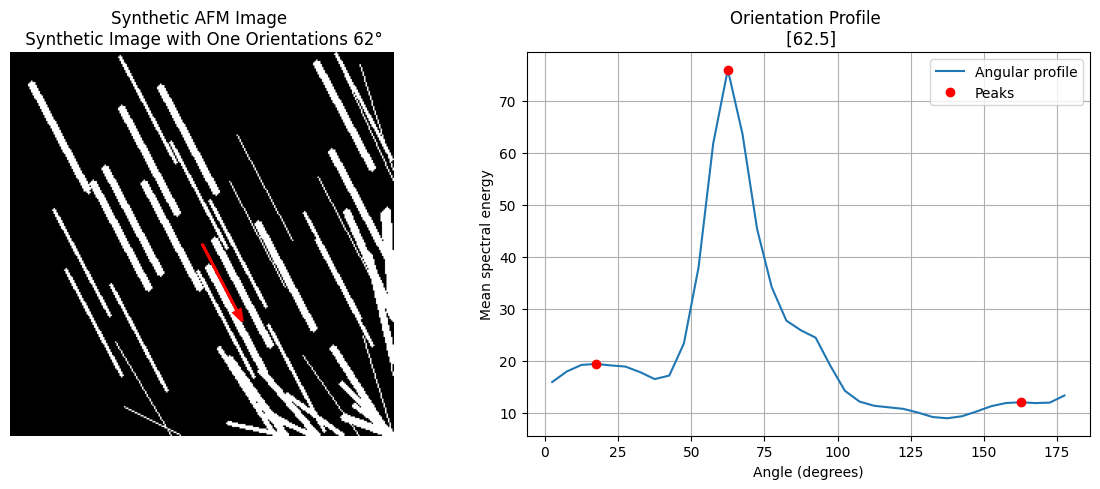

In [6]:
smoothed_angular_profile, peaks, angle_bins = extract_fft_features(img)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, smoothed_angular_profile)

print("Dominant Image orientations (degrees):", dominant_image_orientations)
# --- Example usage ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: image with FFT orientations
title_real_image = f'Synthetic AFM Image \n {title_synthetic_image}'
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red','blue'], arrow_length=50)

# Right panel: angular profile with peaks
ax[0].set_title(title_real_image)
ax[1].plot(angle_bins, smoothed_angular_profile, label='Angular profile')
ax[1].plot(angle_bins[peaks], smoothed_angular_profile[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Mean spectral energy")
ax[1].set_title(f"Orientation Profile \n {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


Dominant Image orientations (degrees): [62.5]


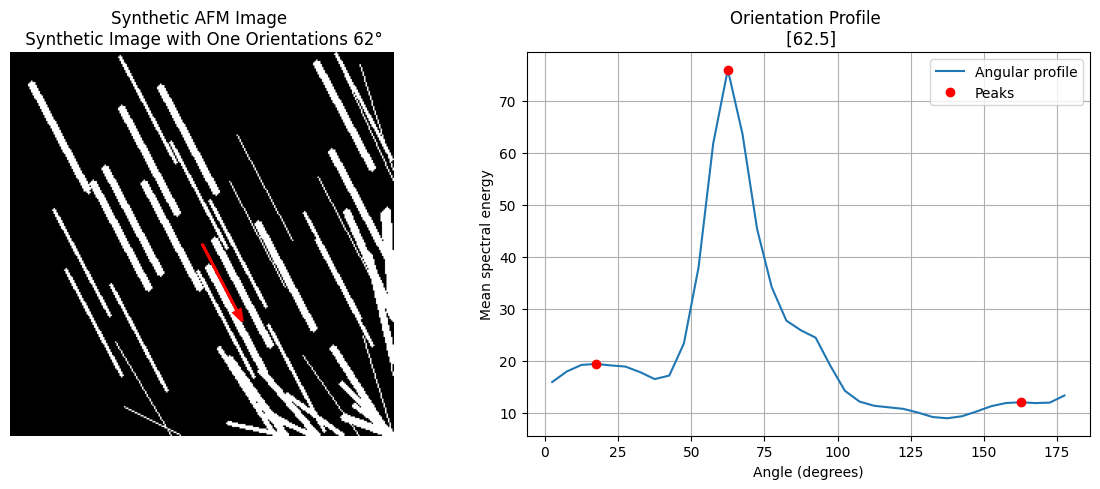

In [7]:
smoothed_angular_profile, peaks, angle_bins = extract_fft_features(img)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, smoothed_angular_profile)

print("Dominant Image orientations (degrees):", dominant_image_orientations)
# --- Example usage ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: image with FFT orientations
title_real_image = f'Synthetic AFM Image \n {title_synthetic_image}'
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red','blue'], arrow_length=50)

# Right panel: angular profile with peaks
ax[0].set_title(title_real_image)
ax[1].plot(angle_bins, smoothed_angular_profile, label='Angular profile')
ax[1].plot(angle_bins[peaks], smoothed_angular_profile[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Mean spectral energy")
ax[1].set_title(f"Orientation Profile \n {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


## Real AFM image of CNTs

In [8]:
import os 
print(os.getcwd())

c:\Users\abd93000\PycharmProjects\cnt_project_v2\testing\Notebooks\Use_case_CNT_orientation_analysis\Use_case_CNT_orientation_analysis\notebooks


Dominant Image orientations (degrees): [92.5]


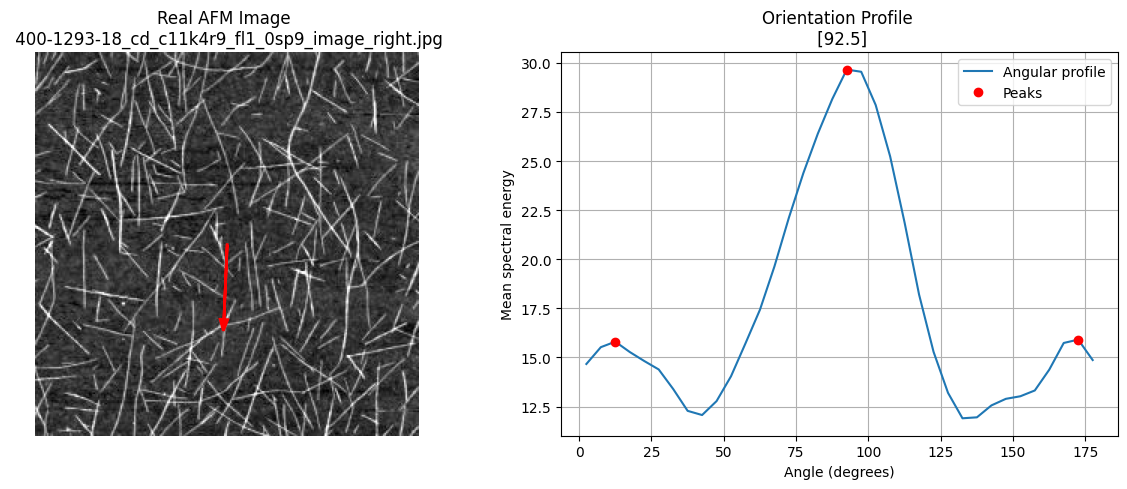

In [9]:
base_path = r'C:\Users\abd93000\PycharmProjects\cnt_project_v2\testing\data\annotations_uniques\test'
selected_folder = os.path.join(base_path, 'images')
images = list_images(selected_folder)
sample = random.choice(images)
img = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)



smoothed_angular_profile, peaks, angle_bins = extract_fft_features(img)
dominant_image_orientations = find_main_orientation(peaks, angle_bins, smoothed_angular_profile)

print("Dominant Image orientations (degrees):", dominant_image_orientations)
# --- Example usage ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: image with FFT orientations
title_real_image = f'Real AFM Image \n {os.path.basename(sample)}'
show_angle_orientation(ax[0], img, dominant_image_orientations[:2], colors=['red','blue'], arrow_length=50)

# Right panel: angular profile with peaks
ax[0].set_title(title_real_image)
ax[1].plot(angle_bins, smoothed_angular_profile, label='Angular profile')
ax[1].plot(angle_bins[peaks], smoothed_angular_profile[peaks], 'ro', label='Peaks')
ax[1].set_xlabel("Angle (degrees)")
ax[1].set_ylabel("Mean spectral energy")
ax[1].set_title(f"Orientation Profile \n {dominant_image_orientations[:2]}")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

# Run through all images

In [10]:
import sys
import os
import importlib
# Add the project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
    
# importlib.reload(sys.modules['src.orientation_metrics'])
# importlib.reload(sys.modules['src.visualization'])
# importlib.reload(sys.modules['src.fft_utils'])


from src.io_utils import list_images
from src.orientation_metrics import find_main_orientation
from src.visualization import show_angle_orientation

import pandas as pd, os, random, cv2

In [11]:
base_path = r'C:\Users\abd93000\PycharmProjects\cnt_project_v2\testing\data\annotations_uniques\test'
save_output = r'C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features\original_images'
selected_folder = os.path.join(base_path, 'images')

# --- Main batch processing ---

images = list_images(selected_folder)
orientation_list = []

# Ensure output directory exists
os.makedirs(save_output, exist_ok=True)

for sample in images:
    img = cv2.imread(sample, cv2.IMREAD_GRAYSCALE)

    smoothed_angular_profile, peaks, angle_bins = extract_fft_features(img)
    dominant_image_orientations = find_main_orientation(peaks, angle_bins, smoothed_angular_profile)

    print(f"{os.path.basename(sample)} → Dominant orientations: {dominant_image_orientations}")



    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Left: show image with dominant orientations (limit to 4)
    title_real_image = f'Real AFM Image: \n {os.path.basename(sample)}'
    show_angle_orientation(ax[0], img, dominant_image_orientations, colors=['r','b','g','y'], arrow_length=50)
    ax[0].set_title(title_real_image)

    # Right: angular profile with peaks
    ax[1].plot(angle_bins, smoothed_angular_profile, label='Angular profile')
    ax[1].plot(angle_bins[peaks], smoothed_angular_profile[peaks], 'ro', label='Peaks')
    ax[1].set_xlabel("Angle (degrees)")
    ax[1].set_ylabel("Mean spectral energy")
    ax[1].set_title(f"Orientation Profile \n {dominant_image_orientations}")
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout()

    # Save figure
    save_fig_path = os.path.join(save_output, os.path.basename(sample) + '_fft.png')
    fig.savefig(save_fig_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    ori_padded = np.full(2, np.nan)
    ori_padded[:len(dominant_image_orientations)] = dominant_image_orientations[:2]

    orientation_list.append({
        'filename': os.path.basename(sample),
        'orientation_1_deg': ori_padded[0],
        'orientation_2_deg': ori_padded[1],

    })

# Save all to CSV
df_orientations = pd.DataFrame(orientation_list)
csv_path = os.path.join(save_output, 'orientations.csv')
df_orientations.to_csv(csv_path, index=False)

print(f"Saved orientation summary → {csv_path}")

1293-22_3_2_20230306222551.jpg → Dominant orientations: [12.5]
400-1093-w11-c1p1-befo3-10sp-15flow_left.jpg → Dominant orientations: [167.5]
400-1093-w11-c1p2-befo3-20sp-15flow_left.jpg → Dominant orientations: [167.5]
400-1093-w13-c1-p1-10sp-15flow_left.jpg → Dominant orientations: [157.5]
400-1093-w16-c-1-p1-10sp-15flow_left.jpg → Dominant orientations: [12.5]
400-1093-w17-c1p3-20sp-03flow_right.jpg → Dominant orientations: [162.5]
400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right.jpg → Dominant orientations: [2.5]
400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.jpg → Dominant orientations: [97.5]
400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.jpg → Dominant orientations: [167.5]
400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right.jpg → Dominant orientations: [172.5]
400-1293-18_cd_c11k4r9_fl1_0sp9_image_right.jpg → Dominant orientations: [92.5]
400-1293-18_cd_c1k1r3_fl0_3sp0_3_image_left.jpg → Dominant orientations: [97.5]
400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.jpg → Dominant orientations: [92.5]
400-1293-23_3_

# FFT of binary groundtruth masks

In [12]:
import os
import json
import numpy as np
import cv2
from pycocotools import mask as maskUtils

def load_coco_image_and_mask(coco_data, image_filename):
    """
    Load an image and its binary mask from a COCO annotation file.

    Args:
        coco_json_path (str): Path to the COCO-format JSON file.
        images_dir (str): Directory containing the images.
        image_filename (str): Filename of the image to load.

    Returns:
        tuple: (image, mask)
            image: np.ndarray (H, W, C)
            mask: np.ndarray (H, W) — binary (0 background, 1 segmented region)
    """


    # Find image entry
    image_entry = next((img for img in coco_data["images"] if img["file_name"] == image_filename), None)
    if image_entry is None:
        raise ValueError(f"Image '{image_filename}' not found in COCO JSON")

    image_id = image_entry["id"]
    height, width = image_entry["height"], image_entry["width"]



    # Create empty binary mask
    mask = np.zeros((height, width), dtype=np.uint8)

    # Get annotations for this image
    annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_id]

    for ann in annotations:
        seg = ann["segmentation"]


        # Polygon segmentation
        for poly in seg:
            pts = np.array(poly).reshape(-1, 2)
            cv2.fillPoly(mask, [pts.astype(np.int32)], 1)



    return mask


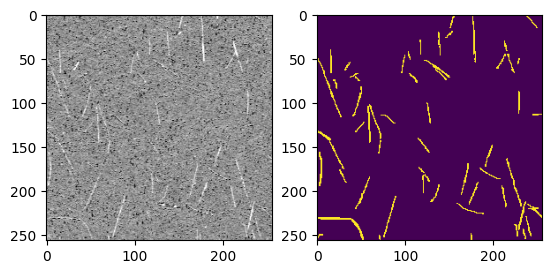

In [14]:
# base_path = r'C:\Users\lud44009\Documents\Projects\20240513 - A.Cherchari\PBC\data\annotations_filtered_artifacts\test'
# save_output = r'C:\Users\lud44009\Documents\Projects\20240513 - A.Cherchari\PBC\output\fft_analysis_groundtruth'
selected_folder = os.path.join(base_path, 'images')

json_path = os.path.join(base_path, 'COCO_mask', 'annotations.json' )
with open(json_path, "r") as f:
    coco_data = json.load(f)


image = load_coco_image_and_mask(coco_data, os.path.basename(sample))
original_image = plt.imread(sample)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(original_image)
ax[1].imshow(image)

In [15]:
# base_path = r'C:\Users\lud44009\Documents\Projects\20240513 - A.Cherchari\PBC\data\annotations_filtered_artifacts\test'
save_output = r'C:\Users\abd93000\Downloads\downloads\paper figures\FFT based features\GT_images'
selected_folder = os.path.join(base_path, 'images')
json_path = os.path.join(base_path, 'COCO_mask', 'annotations.json' )
with open(json_path, "r") as f:
    coco_data = json.load(f)

# --- Main batch processing ---

images = list_images(selected_folder)
orientation_list = []

# Ensure output directory exists
os.makedirs(save_output, exist_ok=True)

for sample in images:
    # replace the original image by the binary image of loaded annotations
    img =  load_coco_image_and_mask(coco_data, os.path.basename(sample))

    smoothed_angular_profile, peaks, angle_bins = extract_fft_features(img)
    dominant_image_orientations = find_main_orientation(peaks, angle_bins, smoothed_angular_profile)

    print(f"{os.path.basename(sample)} → Dominant orientations: {dominant_image_orientations}")



    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Left: show image with dominant orientations (limit to 4)
    title_real_image = f'Real AFM Image: \n {os.path.basename(sample)}'
    show_angle_orientation(ax[0], img, dominant_image_orientations, colors=['r','b','g','y'], arrow_length=50)
    ax[0].set_title(title_real_image)

    # Right: angular profile with peaks
    ax[1].plot(angle_bins, smoothed_angular_profile, label='Angular profile')
    ax[1].plot(angle_bins[peaks], smoothed_angular_profile[peaks], 'ro', label='Peaks')
    ax[1].set_xlabel("Angle (degrees)")
    ax[1].set_ylabel("Mean spectral energy")
    ax[1].set_title(f"Orientation Profile \n{dominant_image_orientations}")
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout()

    # Save figure
    save_fig_path = os.path.join(save_output, os.path.basename(sample) + '_fft.png')
    fig.savefig(save_fig_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

    ori_padded = np.full(2, np.nan)
    ori_padded[:len(dominant_image_orientations)] = dominant_image_orientations[:2]

    orientation_list.append({
        'filename': os.path.basename(sample),
        'orientation_1_deg': ori_padded[0],
        'orientation_2_deg': ori_padded[1],
    })

# Save all to CSV
df_orientations = pd.DataFrame(orientation_list)
csv_path = os.path.join(save_output, 'orientations.csv')
df_orientations.to_csv(csv_path, index=False)

print(f"Saved orientation summary → {csv_path}")

1293-22_3_2_20230306222551.jpg → Dominant orientations: [2.5]
400-1093-w11-c1p1-befo3-10sp-15flow_left.jpg → Dominant orientations: [167.5]
400-1093-w11-c1p2-befo3-20sp-15flow_left.jpg → Dominant orientations: [172.5]
400-1093-w13-c1-p1-10sp-15flow_left.jpg → Dominant orientations: [157.5]
400-1093-w16-c-1-p1-10sp-15flow_left.jpg → Dominant orientations: [12.5]
400-1093-w17-c1p3-20sp-03flow_right.jpg → Dominant orientations: [97.5]
400-1293-17-c10k1r5_pd_sp0_9_fl0_1_right.jpg → Dominant orientations: [2.5]
400-1293-17-c3k1r5_pd_sp0_3_fl0_1_left.jpg → Dominant orientations: [97.5]
400-1293-17-c3k1r5_pd_sp0_3_fl0_1_right.jpg → Dominant orientations: [2.5]
400-1293-17-c79k1r5_pd_sp0_6_fl0_1_right.jpg → Dominant orientations: [167.5]
400-1293-18_cd_c11k4r9_fl1_0sp9_image_right.jpg → Dominant orientations: [92.5]
400-1293-18_cd_c1k1r3_fl0_3sp0_3_image_left.jpg → Dominant orientations: [97.5]
400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.jpg → Dominant orientations: [92.5]
400-1293-23_3_0_20